In [62]:
from pathlib import Path
import sys
import pandas as pd

# Make project root importable whether CWD is repo root or notebooks/
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io import load_run, load_runs
from src.preprocess import (
    qc_report,
    plot_sanity,
    plot_dt_diagnostics,
    bias_from_first_seconds,
    time_range,
    sensor_channel_checks,
    save_qc_outputs,
    build_dataset_qc_table,
    split_qc_pass_fail,
)

In [63]:
# Select one run for detailed QC
RUN_DIR = PROJECT_ROOT / 'data' / 'raw' / 'Farm' / 'Run2'
run = load_run(RUN_DIR, include_pose=False)
acc, gyro, odo = run.acc, run.gyro, run.odo

print('Run:', run.run_id)
for name, df in [('acc', acc), ('gyro', gyro), ('odo', odo)]:
    print(f'{name}: n={len(df)}, t_rel=[{df.t_rel.min():.3f}, {df.t_rel.max():.3f}] s')

acc.head(), gyro.head(), odo.head()


Run: Run2
acc: n=76427, t_rel=[0.002, 917.380] s
gyro: n=75116, t_rel=[0.001, 901.630] s
odo: n=75917, t_rel=[0.000, 911.222] s


(              t      ax      ay      az   t_rel
 0  1.776765e+09  0.0490 -0.9993 -0.0114  0.0018
 1  1.776765e+09  0.0514 -0.9995 -0.0080  0.0143
 2  1.776765e+09  0.0499 -1.0049 -0.0106  0.0257
 3  1.776765e+09  0.0504 -1.0007 -0.0115  0.0380
 4  1.776765e+09  0.0567 -1.0010 -0.0154  0.0504,
               t      gx       gy      gz   t_rel
 0  1.776765e+09 -3.5422 -10.0684 -1.7516  0.0014
 1  1.776765e+09 -3.4659 -10.0379 -1.4468  0.0129
 2  1.776765e+09 -3.4559 -10.0074 -1.6021  0.0253
 3  1.776765e+09 -3.6033 -10.1905 -1.6416  0.0368
 4  1.776765e+09 -3.6012 -10.0684 -1.7674  0.0492,
               t   v1   v2   t_rel
 0  1.776765e+09 -0.0  0.0  0.0000
 1  1.776765e+09 -0.0  0.0  0.0116
 2  1.776765e+09 -0.0  0.0  0.0241
 3  1.776765e+09 -0.0  0.0  0.0355
 4  1.776765e+09 -0.0  0.0  0.0480)

In [64]:
# Single-run QC report table
single_run_qc = qc_report(run.sensors(), tcol='t_rel').set_index('sensor')
single_run_qc


,n,duration_s,fs_med_hz,dt_med,dt_p99,dt_max,gap_ratio_dtmax_over_dtmed,n_gaps_gt_factor_times_med
sensor,,,,,,,,
acc,76427,917.3777,81.300717,0.0123,0.0128,0.0284,2.308936,0
gyro,75116,901.6284,81.300717,0.0123,0.0128,0.0285,2.317058,0
odo,75917,911.2223,81.300717,0.0123,0.0128,0.0284,2.308936,0


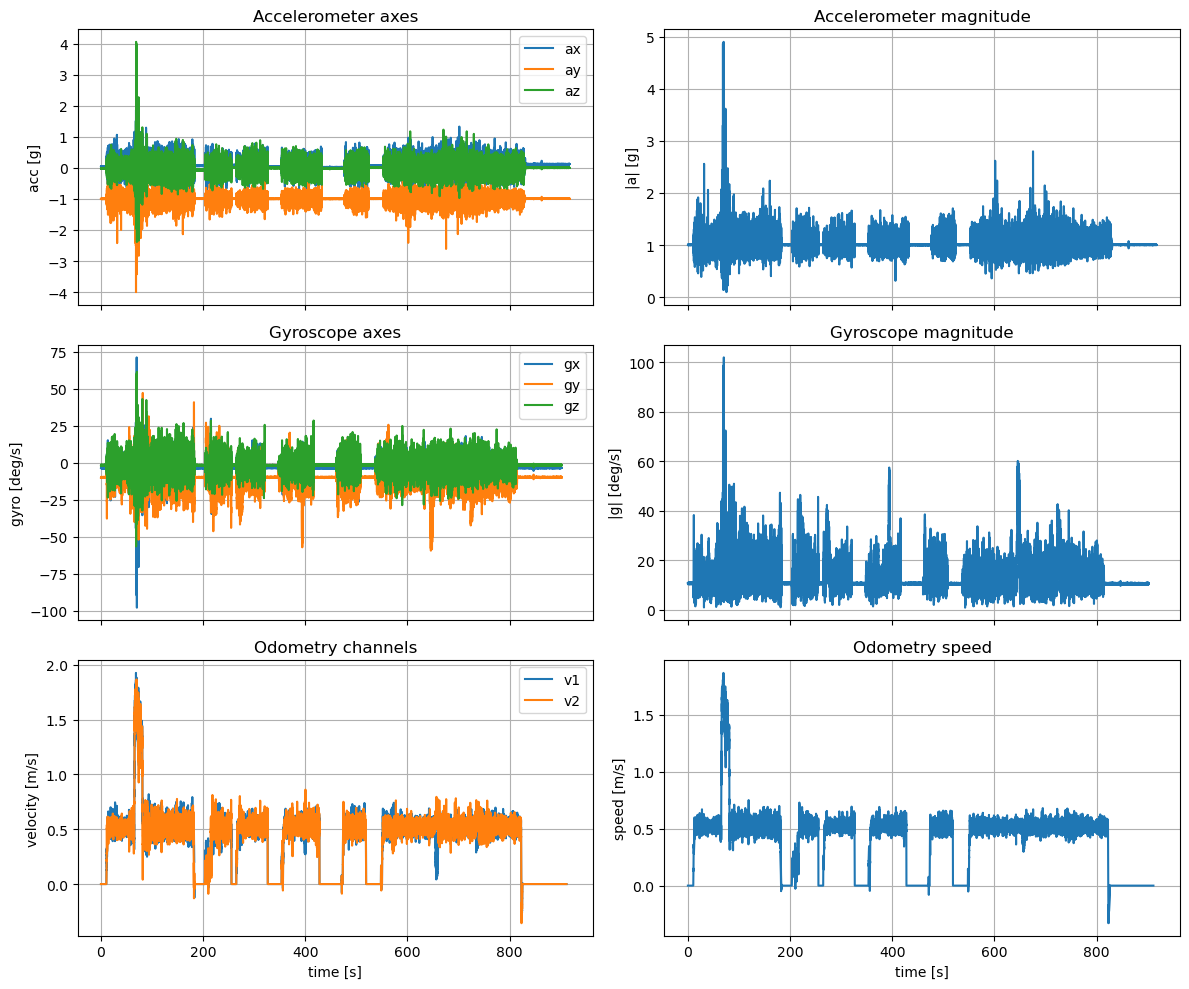

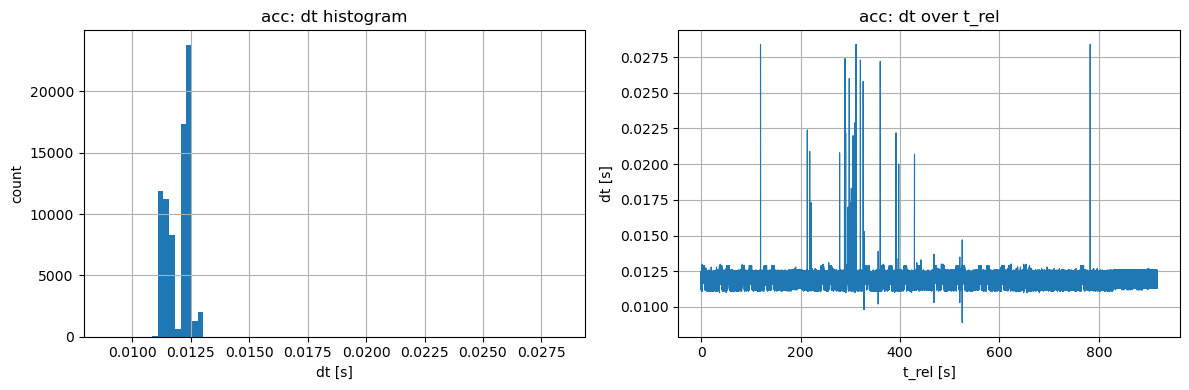

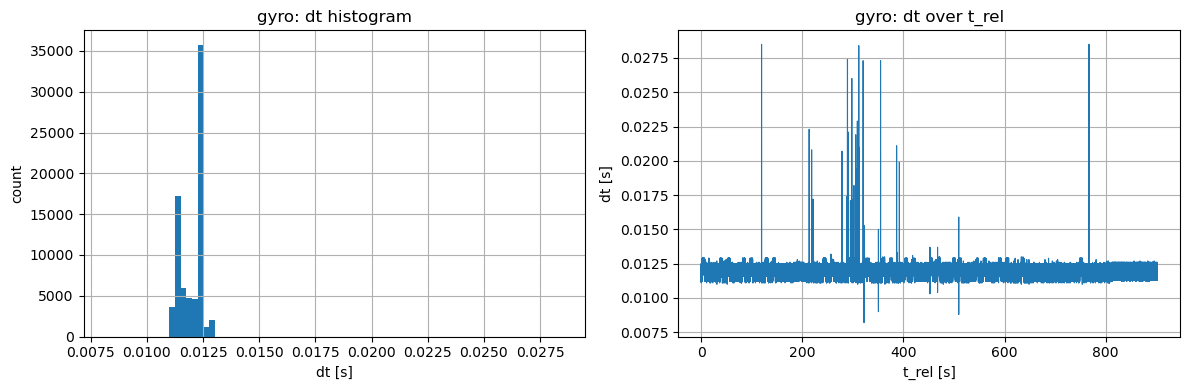

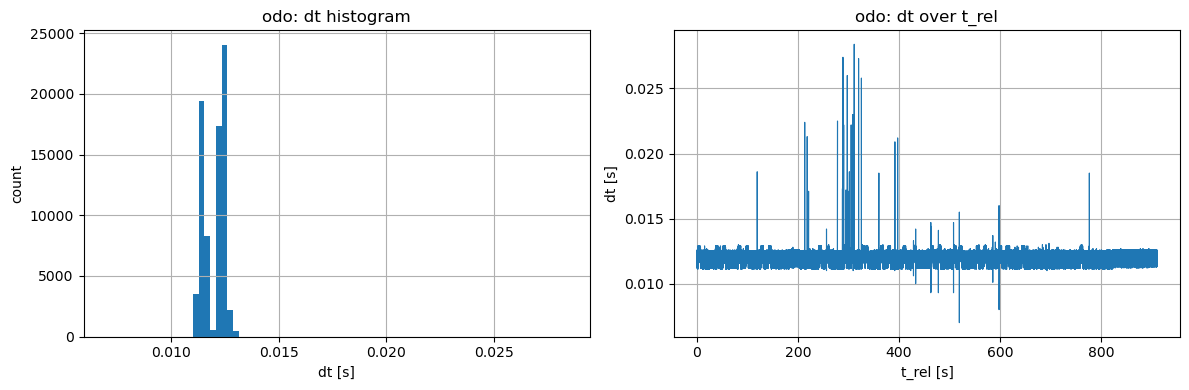

In [65]:
# Single-run sanity plots + dt diagnostics
plot_sanity(acc, gyro, odo, tcol='t_rel', show=True)
for sensor_name, df in [('acc', acc), ('gyro', gyro), ('odo', odo)]:
    fig = plot_dt_diagnostics(sensor_name, df, tcol='t_rel', bins=80, show=True)
    if fig is None:
        print(f'{sensor_name}: not enough samples for dt diagnostics')


In [66]:
# Bias/time-range and sensor saturation checks
gyro_bias = bias_from_first_seconds(gyro, ['gx', 'gy', 'gz'], tcol='t_rel', seconds=5)
acc_bias = bias_from_first_seconds(acc, ['ax', 'ay', 'az'], tcol='t_rel', seconds=5)
acc_mag_median_5s = ((acc['ax']**2 + acc['ay']**2 + acc['az']**2) ** 0.5)[acc['t_rel'] <= 5].median()

print('Gyro bias (first 5s):')
print(gyro_bias)
print('\nAcc mean (first 5s):')
print(acc_bias)
print('\nAcc |a| median (first 5s):', float(acc_mag_median_5s) if pd.notna(acc_mag_median_5s) else float('nan'))

ranges = pd.DataFrame(
    {
        'sensor': ['acc', 'gyro', 'odo'],
        't_min': [time_range(acc)[0], time_range(gyro)[0], time_range(odo)[0]],
        't_max': [time_range(acc)[1], time_range(gyro)[1], time_range(odo)[1]],
    }
).set_index('sensor')
print('\nTime ranges (t_rel):')
ranges

range_sat_checks = pd.concat(
    [
        sensor_channel_checks(acc, ['ax', 'ay', 'az'], 'acc'),
        sensor_channel_checks(gyro, ['gx', 'gy', 'gz'], 'gyro'),
    ],
    ignore_index=True,
)
print('\nRange/saturation checks:')
range_sat_checks


Gyro bias (first 5s):
gx   -3.514429
gy   -9.953016
gz   -1.718476
dtype: float64

Acc mean (first 5s):
ax    0.050713
ay   -1.001176
az   -0.013195
dtype: float64

Acc |a| median (first 5s): 1.0025854826397598

Time ranges (t_rel):

Range/saturation checks:


,sensor,channel,max_abs,n,n_unique,repeat_ratio,longest_constant_run,clip_candidate_count,flag_frozen,flag_flat_top
0,acc,ax,2.4657,76427,10274,0.002251,2,1,False,False
1,acc,ay,3.9999,76427,4019,0.008034,3,1,False,False
2,acc,az,4.0537,76427,9466,0.002251,3,1,False,False
3,gyro,gx,97.9766,75116,47629,0.001132,3,1,False,False
4,gyro,gy,59.4459,75116,2215,0.018664,4,1,False,False
5,gyro,gz,61.3531,75116,48352,0.001132,3,1,False,False


In [67]:
# Save QC artifacts per run (mirrors data/raw labels under reports/raw)
RAW_ROOT = PROJECT_ROOT / 'data' / 'raw'
MAIN_ROOT = RAW_ROOT/ 'Main'
FARM_ROOT = RAW_ROOT / 'Farm'
ARTIFACT_ROOT = PROJECT_ROOT / 'reports' / 'raw'
runs_for_artifacts = load_runs(MAIN_ROOT, include_pose=False)
runs_for_artifacts.append(load_run(FARM_ROOT / "Run1", include_pose=False))
runs_for_artifacts.append(load_run(FARM_ROOT / "Run2", include_pose=False))

save_qc_outputs(runs_for_artifacts, raw_root=RAW_ROOT, out_root=ARTIFACT_ROOT, tcol='t_rel')
print(f'Saved QC artifacts for {len(runs_for_artifacts)} runs to: {ARTIFACT_ROOT}')


Saved QC artifacts for 6 runs to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/raw


In [ ]:
# Multi-run QC dashboard + pass/fail filtering
MAIN_ROOT = RAW_ROOT/ 'Main'
FARM_ROOT = RAW_ROOT / 'Farm'
runs = load_runs(MAIN_ROOT, include_pose=False)
runs.append(load_run(FARM_ROOT / "Run1", include_pose=False))
runs.append(load_run(FARM_ROOT / "Run2", include_pose=False))


"""A run is good if pass_all == True. pass_all is true only if all are true:
- pass_dt_gaps: no large timestamp gaps in any sensor (n_gaps_gt_factor_times_med == 0), where large gap means dt > 5 * median_dt
- pass_duration: each sensor duration is at least min_duration_s (here we use 30s)
- pass_fs: median sample rate in expected range:
    - acc: 70-100 Hz
    - gyro: 70-100 Hz
    - odo: 80-130 Hz
"""
dataset_qc = build_dataset_qc_table(runs, tcol='t_rel', min_duration_s=30.0)
dataset_qc_good, dataset_qc_bad, good_run_ids, bad_run_ids = split_qc_pass_fail(dataset_qc)

print('Good runs:', len(good_run_ids))
print(good_run_ids)
print('Bad runs:', len(bad_run_ids))
print(bad_run_ids)

dataset_qc


Good runs: 6
['Run1', 'Run2', 'log_20260223_142511.490', 'log_20260226_102148.990', 'log_20260309_141435.414', 'log_20260326_120021.508']
Bad runs: 0
[]


,acc__n,acc__duration_s,acc__fs_med_hz,acc__dt_med,acc__dt_p99,acc__dt_max,acc__gap_ratio_dtmax_over_dtmed,acc__n_gaps_gt_factor_times_med,gyro__n,gyro__duration_s,...,odo__fs_med_hz,odo__dt_med,odo__dt_p99,odo__dt_max,odo__gap_ratio_dtmax_over_dtmed,odo__n_gaps_gt_factor_times_med,pass_dt_gaps,pass_duration,pass_fs,pass_all
run_id,,,,,,,,,,,,,,,,,,,,,
Run1,43992.0,528.0803,81.300717,0.0123,0.0128,0.0292,2.373987,0.0,47023.0,564.4680,...,81.300717,0.0123,0.0128,0.0273,2.219500,0.0,True,True,True,True
Run2,76427.0,917.3777,81.300717,0.0123,0.0128,0.0284,2.308936,0.0,75116.0,901.6284,...,81.300717,0.0123,0.0128,0.0284,2.308936,0.0,True,True,True,True
log_20260223_142511.490,243359.0,2920.4082,83.332751,0.0120,0.0130,0.0279,2.324982,0.0,243378.0,2920.6368,...,129.870696,0.0077,0.0088,0.0248,3.220801,0.0,True,True,True,True
log_20260226_102148.990,181067.0,2172.7994,83.332751,0.0120,0.0130,0.0177,1.474986,0.0,182779.0,2193.3403,...,129.870696,0.0077,0.0088,0.0164,2.129861,0.0,True,True,True,True
log_20260309_141435.414,299880.0,3598.7316,83.332751,0.0120,0.0130,0.0184,1.533319,0.0,299924.0,3599.2593,...,129.870696,0.0077,0.0088,0.0161,2.090940,0.0,True,True,True,True
log_20260326_120021.508,154168.0,1850.0146,83.332751,0.0120,0.0130,0.0181,1.508325,0.0,154117.0,1849.3997,...,129.870696,0.0077,0.0088,0.0149,1.935069,0.0,True,True,True,True
